# Layer-1 and Layer-2 Self-Attention Ablation — Query Positions 1 and 2

**Goal:** Test whether self-attention *within layer 1* and *within layer 2* (Dr. Liu's
1-indexed convention, i.e. HF 0-indexed `model.model.layers[0]` and `model.model.layers[1]`)
is causally responsible for the gate-vector sign flip observed at token positions 1 and 2
(relative to position 0). For each query position in `QUERY_POSITIONS`, this notebook runs
three conditions:

1. **Layer-1-only ablation** — block attention from the query position back to the earlier
   position(s) at layer 1 alone, read out layer 1.
2. **Layer-2-only ablation** — same block, at layer 2 alone, read out layer 2.
   (1) and (2) are independent single-layer interventions, each its own fresh forward pass —
   layer 1's ablation is **not** present when testing layer 2 in isolation.
3. **Combined/propagated ablation** — block the same key position(s) at **both** layer 1 and
   layer 2 *simultaneously, in the same forward pass*, and read out layer 2. Because this is one
   forward pass, layer 2 here processes the residual stream that already reflects layer 1's
   ablation — i.e. layer 1's perturbation propagates into layer 2's input, on top of layer 2's
   own local attention block. Comparing condition (3) against condition (2) isolates the
   causal contribution of layer 1's ablation *propagating through* to layer 2, as opposed to
   layer 2's local ablation alone.

**Intervention:** For a given query position `q` at a given layer `L`, block attention to the
key position(s) in `KEY_POS_TO_BLOCK[q]` (set the pre-softmax score to `-inf`). At query
position 1, the causal mask only allows keys `{0, 1}`, so blocking key 0
(`KEY_POS_TO_BLOCK[1] == [0]`) automatically forces softmax to put 100% of the attention weight
on key 1 (itself). At query position 2, the causal mask allows keys `{0, 1, 2}`, so to get the
same "attend to itself only" effect we block **both** earlier keys
(`KEY_POS_TO_BLOCK[2] == [0, 1]`).

**Indexing note:** `LAYERS_TO_TEST = [0, 1]` are 0-indexed HF layers
(`model.model.layers[0]`, `model.model.layers[1]`), corresponding to Dr. Liu's
1-indexed "layer 1" and "layer 2". Confirm this matches the layer where
`verify_ma_circuit_layer2.py` located neuron 2427 before trusting the result.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16

# 0-indexed HF layers to intervene on, run in this order.
# LAYERS_TO_TEST[0] == 0  -> Dr. Liu's 1-indexed "layer 1"
# LAYERS_TO_TEST[1] == 1  -> Dr. Liu's 1-indexed "layer 2"
LAYERS_TO_TEST = [0, 1]
LAYER_LABELS = {0: "layer 1", 1: "layer 2"}  # Dr. Liu's 1-indexed naming, for titles/filenames

NEURON_IDX = 2427  # MA-implicated gate neuron
QUERY_POSITIONS = [1, 2]  # token positions under test
KEY_POS_TO_BLOCK = {
    1: [0],     # causal mask only allows keys {0,1} at query pos 1 -> forces 100% self-attention
    2: [0, 1],  # causal mask allows keys {0,1,2} at query pos 2 -> block both earlier keys for the same effect
}

OUTPUT_DIR = "outputs/attention_ablation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.manual_seed(0)

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=DTYPE,
    attn_implementation="eager",  # required: need explicit additive attention_mask access
).to(DEVICE)
model.eval()
print(model.config.num_hidden_layers, "layers | hidden_size:", model.config.hidden_size)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

32 layers | hidden_size: 4096


## Step 0 — Verify layer indexing empirically (don't trust convention alone)

Per project convention, `hidden_states[i]` = output of `model.model.layers[i-1]`.
So Dr. Liu's "layer 1" and "layer 2" (matching his MATLAB, 1-indexed analysis) most likely
correspond to `model.model.layers[0]` and `model.model.layers[1]` in HF's 0-indexed
`ModuleList` — this is exactly `LAYERS_TO_TEST` above. Rather than trust that mapping
blindly, re-derive which HF indices actually contain the MA circuit: check `down_proj`'s
column for neuron 2427 and see which candidate layer's row-norm is dominated by the three
MA channels (788, 1384, 4062), same test as `verify_ma_circuit_layer2.py`.

In [3]:
len(model.model.layers)

32

## Prepare input

Replace `PROMPT` with one of your existing harmful/harmless examples. `add_special_tokens=False`
with an explicit BOS assertion, per established convention — avoids silently
double-adding BOS depending on tokenizer defaults.

In [4]:
PROMPT = "me Tell a joke"  # placeholder — replace with your dataset example

BOS_ID = tokenizer.bos_token_id
ids = tokenizer.encode(PROMPT, add_special_tokens=False)
assert ids[0] != BOS_ID, "First token unexpectedly matches BOS id — check tokenizer/prompt"

input_ids = torch.tensor([ids], device=DEVICE)
print("token ids:", ids)
print("tokens:   ", [tokenizer.decode([t]) for t in ids])
assert input_ids.shape[1] > max(QUERY_POSITIONS), "sequence too short for QUERY_POSITIONS"

token ids: [2727, 25672, 264, 22380]
tokens:    ['me', ' Tell', ' a', ' joke']


## Helpers: capture the gate vector at one or more layers, at a given query position

`capture_activations` takes a **list** of layers to instrument (`capture_layers`) and the
`query_pos` to read out, so a single forward pass can read out activations at multiple layers
at once — needed for the combined condition below, where we block attention at layers 1 and 2
together but want to confirm layer 1's readout is unaffected by layer 2's hook while inspecting
layer 2's propagated readout.

For each layer in `capture_layers`, it hooks `model.model.layers[L].mlp` with a
`forward_pre_hook` to capture its input `x` (the post-RMSNorm, post-gamma residual stream —
exactly what feeds `gate_proj`), from which we compute the full 14,336-dim gate vector
`x @ W_gate.T` ourselves.

`extra_fwd_pre_hooks` is a list of `(module, hook_fn)` pairs applied on top — used to register
the attention-blocking hook(s) on whichever `self_attn` module(s) are under test.
`make_block_hook` now takes a **list** of key positions to block, so it can force full
self-attention at query position 2 (block keys `{0, 1}`) the same way it does at query
position 1 (block key `{0}`).

In [5]:
def capture_activations(model, input_ids, capture_layers, query_pos, extra_fwd_pre_hooks=None):
    """
    Runs a single forward pass, optionally with extra forward_pre_hooks registered
    on self_attn modules (for the attention-blocking intervention).
    Returns a dict {L: {'gate': ..., 'attn': ...}} for every L in
    capture_layers, all read out at position `query_pos`:
      - 'gate': the full gate vector (14336,)
      - 'attn': the attention pattern at layer L, for sanity-checking any block
    """
    captured = {}
    handles = []

    def make_mlp_input_hook(L):
        def hook(module, args):
            captured[('mlp_input', L)] = args[0].detach()
        return hook

    for L in capture_layers:
        handles.append(model.model.layers[L].mlp.register_forward_pre_hook(make_mlp_input_hook(L)))

    if extra_fwd_pre_hooks:
        for module, hook_fn in extra_fwd_pre_hooks:
            handles.append(module.register_forward_pre_hook(hook_fn, with_kwargs=True))

    try:
        with torch.no_grad():
            out = model(input_ids=input_ids, output_attentions=True)
    finally:
        for h in handles:
            h.remove()

    results = {}
    for L in capture_layers:
        x = captured[('mlp_input', L)][0, query_pos, :].to(torch.float32)          # (4096,)
        W_gate = model.model.layers[L].mlp.gate_proj.weight.detach().to(torch.float32)  # (14336, 4096)
        gate_vec = x @ W_gate.T                                                    # (14336,)

        attn_pattern_L = out.attentions[L][0, :, query_pos, :].to(torch.float32)   # (n_heads, seq)

        results[L] = dict(
            gate=gate_vec.cpu().numpy(),
            attn=attn_pattern_L.cpu().numpy(),
        )
    return results


def make_block_hook(query_pos, key_positions, dtype):
    fill_value = torch.finfo(dtype).min

    def hook(module, args, kwargs):
        attention_mask = kwargs.get('attention_mask', None)
        assert attention_mask is not None, (
            "attention_mask kwarg not found on self_attn — check transformers version"
        )
        attention_mask = attention_mask.clone()
        for key_pos in key_positions:
            attention_mask[:, :, query_pos, key_pos] = fill_value
        kwargs['attention_mask'] = attention_mask
        return args, kwargs

    return hook

## Steps 1–2 — Independent single-layer ablation: layer 1 alone, then layer 2 alone

For each query position `q` in `QUERY_POSITIONS` and each `L` in `LAYERS_TO_TEST` (in order:
layer 1, then layer 2), we run two **separate** full forward passes:
1. **Baseline** — no attention-blocking hooks (only the gate-vector capture hook).
2. **Intervention** — attention from query pos `q` to the key position(s) in
   `KEY_POS_TO_BLOCK[q]` blocked at layer `L` only.

These two conditions never involve blocking both layers at once — that's the combined
condition in Step 2b below. Results are stored in `results[q][L]`.

In [6]:
results = {}

for qpos in QUERY_POSITIONS:
    results[qpos] = {}
    key_positions = KEY_POS_TO_BLOCK[qpos]

    for L in LAYERS_TO_TEST:
        label = LAYER_LABELS[L]
        print(f"\n=== query pos {qpos}, {label} (HF index {L}), independent ablation ===")

        baseline = capture_activations(model, input_ids, capture_layers=[L], query_pos=qpos)[L]
        print(f"baseline attn pattern at {label}, query pos {qpos} (per head, keys 0..{qpos}):")
        with np.printoptions(suppress=True, precision=4):
            print(baseline['attn'][:, :qpos + 1])
        print(f"gate_baseline[neuron {NEURON_IDX}] =", baseline['gate'][NEURON_IDX])

        block_hook = make_block_hook(qpos, key_positions, dtype=DTYPE)
        target_module = model.model.layers[L].self_attn
        intervention = capture_activations(
            model, input_ids, capture_layers=[L], query_pos=qpos,
            extra_fwd_pre_hooks=[(target_module, block_hook)]
        )[L]
        print(f"intervention attn pattern at {label}, query pos {qpos} (per head, keys 0..{qpos}):")
        print(intervention['attn'][:, :qpos + 1])
        print(f"-> expect ~0 in blocked key column(s) {key_positions} and the remaining weight "
              f"redistributed over the unblocked key(s), for every head")
        print(f"gate_intervention[neuron {NEURON_IDX}] =", intervention['gate'][NEURON_IDX])

        results[qpos][L] = dict(
            gate_baseline=baseline['gate'],
            gate_intervention=intervention['gate'],
            attn_baseline=baseline['attn'],
            attn_intervention=intervention['attn'],
        )


=== query pos 1, layer 1 (HF index 0), independent ablation ===
baseline attn pattern at layer 1, query pos 1 (per head, keys 0..1):
[[0.377  0.6211]
 [0.3926 0.6094]
 [0.8789 0.1226]
 [0.2734 0.7266]
 [0.6016 0.4004]
 [0.4492 0.5508]
 [0.4219 0.5781]
 [0.6016 0.4004]
 [0.2451 0.7539]
 [0.4922 0.5078]
 [0.2871 0.7109]
 [0.3066 0.6914]
 [0.4941 0.5039]
 [0.5352 0.4648]
 [0.6367 0.3652]
 [0.5977 0.4043]
 [0.6523 0.3477]
 [0.6875 0.3145]
 [0.6523 0.3477]
 [0.4258 0.5742]
 [0.7227 0.2793]
 [0.0713 0.9297]
 [0.0874 0.9141]
 [0.334  0.6641]
 [0.6445 0.3555]
 [0.7539 0.2451]
 [0.793  0.207 ]
 [0.5312 0.4688]
 [0.5078 0.4922]
 [0.957  0.041 ]
 [0.1602 0.8398]
 [0.0229 0.9766]]
gate_baseline[neuron 2427] = -0.05773283
intervention attn pattern at layer 1, query pos 1 (per head, keys 0..1):
[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]


## Step 2b — Combined/propagated ablation: block layer 1 AND layer 2 in the same forward pass

This is the key new condition, run for each query position `q` in `QUERY_POSITIONS`. We
register the attention-block hook on **both** `model.model.layers[0].self_attn` and
`model.model.layers[1].self_attn` at once, in a single forward pass, and read out activations
at **both** layers.

- The layer-1 readout in this combined pass should be numerically identical to the
  layer-1-only intervention above (Transformer layers are strictly causal/feed-forward across
  depth, so layer 2's hook cannot affect layer 1's computation). We assert this as a sanity
  check.
- The layer-2 readout in this combined pass is the interesting one: layer 2 here is processing
  a residual stream that already reflects layer 1's ablation, on top of its own local
  attention block. Comparing this against the layer-2-only intervention (`results[q][1]`, where
  layer 1 was left untouched) isolates how much of the effect at layer 2 is *caused by
  layer 1's ablation propagating forward*, versus layer 2's own local attention block.

In [7]:
for qpos in QUERY_POSITIONS:
    key_positions = KEY_POS_TO_BLOCK[qpos]

    block_hook_L0 = make_block_hook(qpos, key_positions, dtype=DTYPE)
    block_hook_L1 = make_block_hook(qpos, key_positions, dtype=DTYPE)
    target_L0 = model.model.layers[0].self_attn
    target_L1 = model.model.layers[1].self_attn

    combined = capture_activations(
        model, input_ids, capture_layers=[0, 1], query_pos=qpos,
        extra_fwd_pre_hooks=[(target_L0, block_hook_L0), (target_L1, block_hook_L1)],
    )

    # Sanity check: layer-1 readout under the combined hook must match the layer-1-only
    # intervention exactly, since layer 2's hook cannot causally affect layer 1's forward pass.
    assert np.allclose(combined[0]['gate'], results[qpos][0]['gate_intervention']), (
        f"query pos {qpos}: combined layer-1 gate readout diverged from layer-1-only intervention — "
        "something upstream of layer 1 is not deterministic, or the hook wiring is wrong"
    )
    print(f"query pos {qpos}: sanity check passed — layer-1 readout under combined hooking "
          f"matches layer-1-only intervention")

    results[qpos]['combined'] = dict(
        gate_L0=combined[0]['gate'],
        attn_L0=combined[0]['attn'],
        gate_L1=combined[1]['gate'],
        attn_L1=combined[1]['attn'],
    )

    print(f"\ngate[{NEURON_IDX}] at layer 2 readout, query pos {qpos}:")
    print(f"  baseline (nothing blocked)        = {results[qpos][1]['gate_baseline'][NEURON_IDX]:.4f}")
    print(f"  layer-2-only ablation              = {results[qpos][1]['gate_intervention'][NEURON_IDX]:.4f}")
    print(f"  combined (layer-1 + layer-2 ablated) = {results[qpos]['combined']['gate_L1'][NEURON_IDX]:.4f}")

query pos 1: sanity check passed — layer-1 readout under combined hooking matches layer-1-only intervention

gate[2427] at layer 2 readout, query pos 1:
  baseline (nothing blocked)        = -10.1985
  layer-2-only ablation              = 1.1219
  combined (layer-1 + layer-2 ablated) = 19.2634
query pos 2: sanity check passed — layer-1 readout under combined hooking matches layer-1-only intervention

gate[2427] at layer 2 readout, query pos 2:
  baseline (nothing blocked)        = -5.8831
  layer-2-only ablation              = 3.0380
  combined (layer-1 + layer-2 ablated) = 19.8151


## Step 3 — Plot: gate vector at each token position, baseline vs. intervention, per layer (independent)

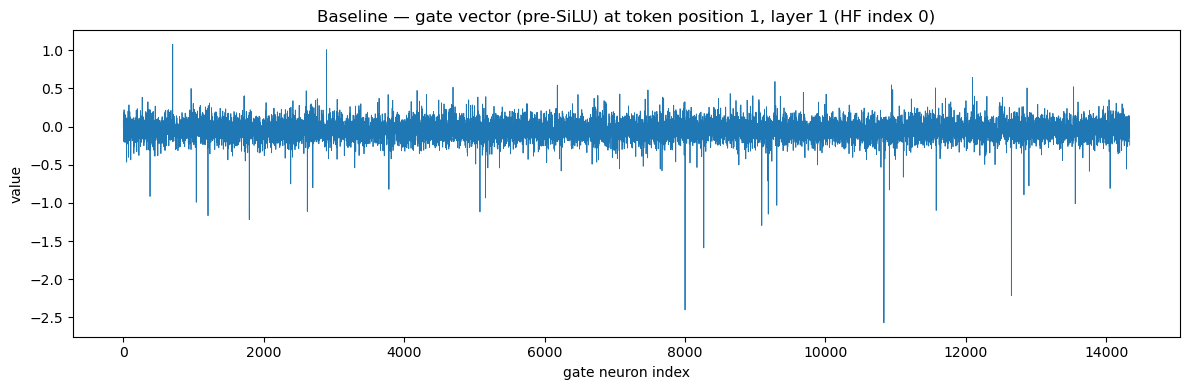

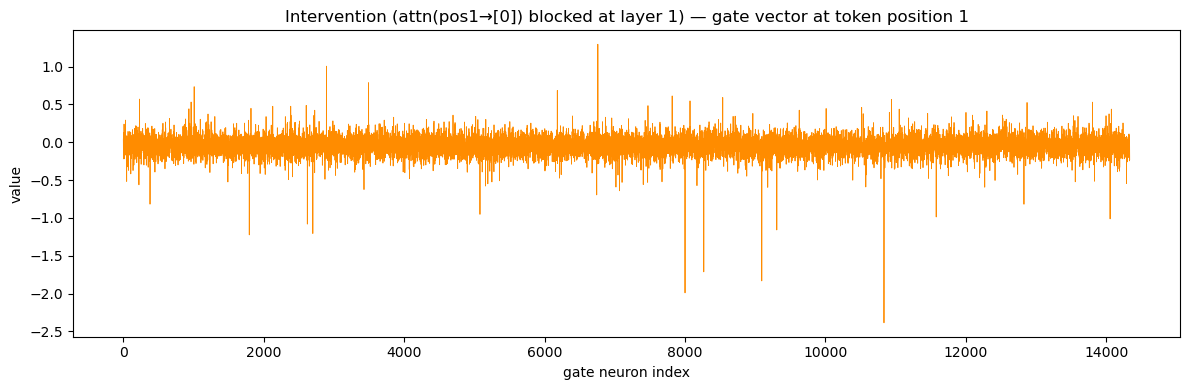

query pos 1, layer 1: neuron 2427: baseline = -0.058  intervention = -0.035
query pos 1, layer 1: sign changed after intervention: False


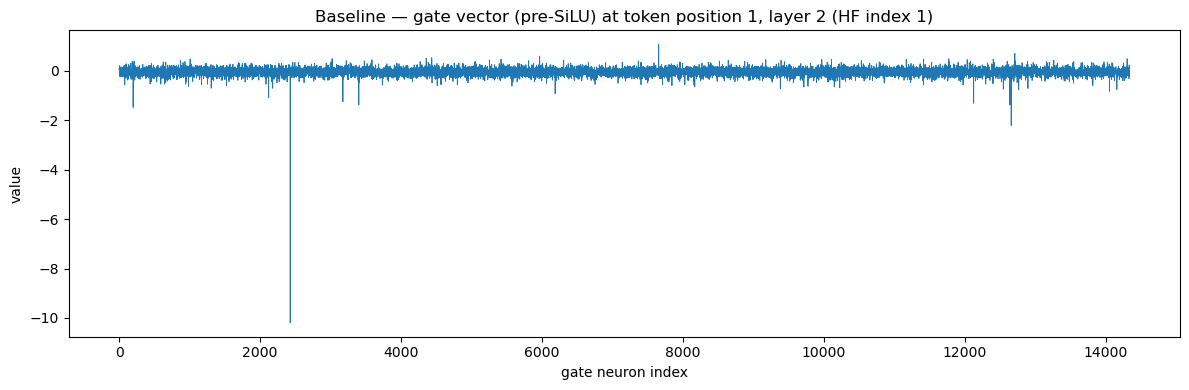

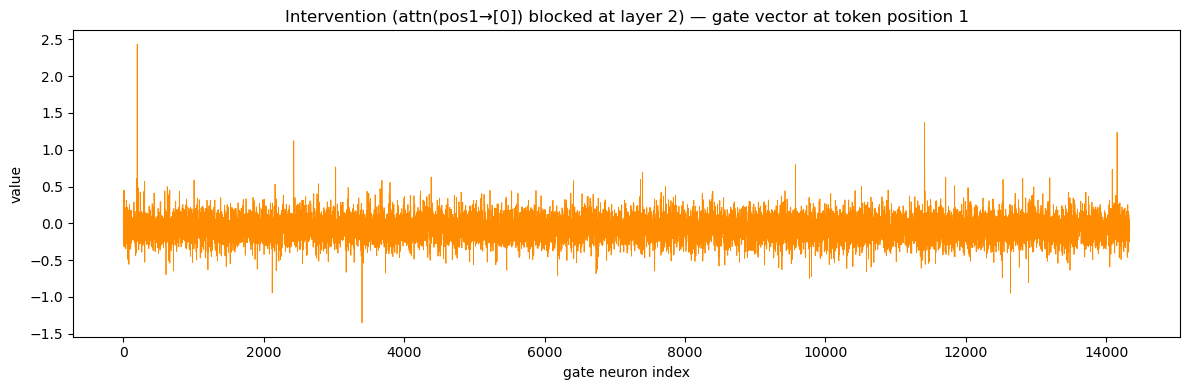

query pos 1, layer 2: neuron 2427: baseline = -10.198  intervention = 1.122
query pos 1, layer 2: sign changed after intervention: True


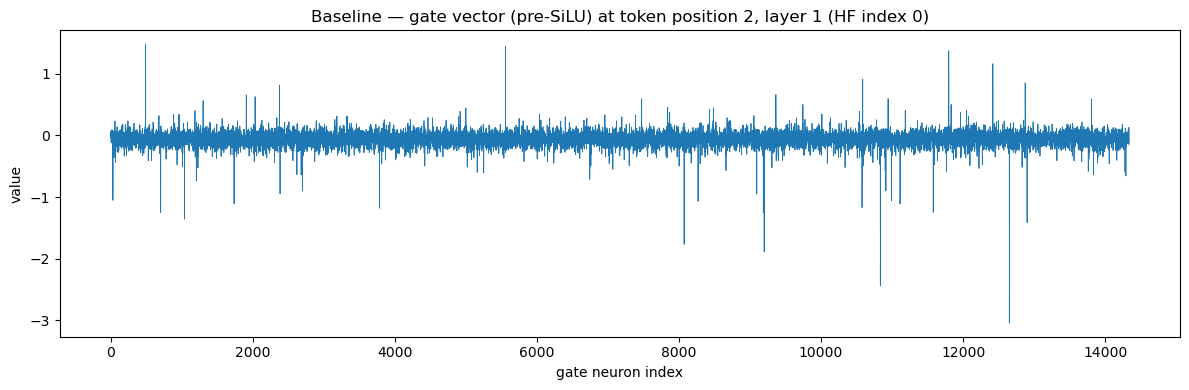

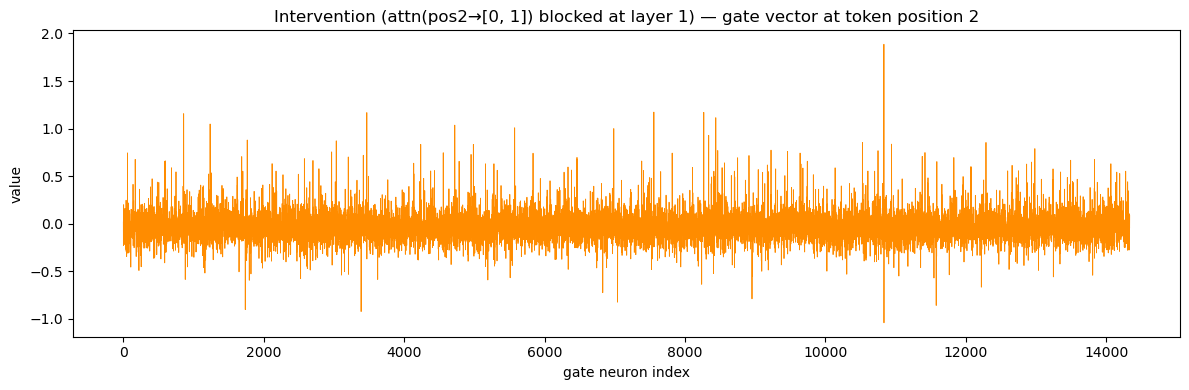

query pos 2, layer 1: neuron 2427: baseline = -0.023  intervention = -0.004
query pos 2, layer 1: sign changed after intervention: False


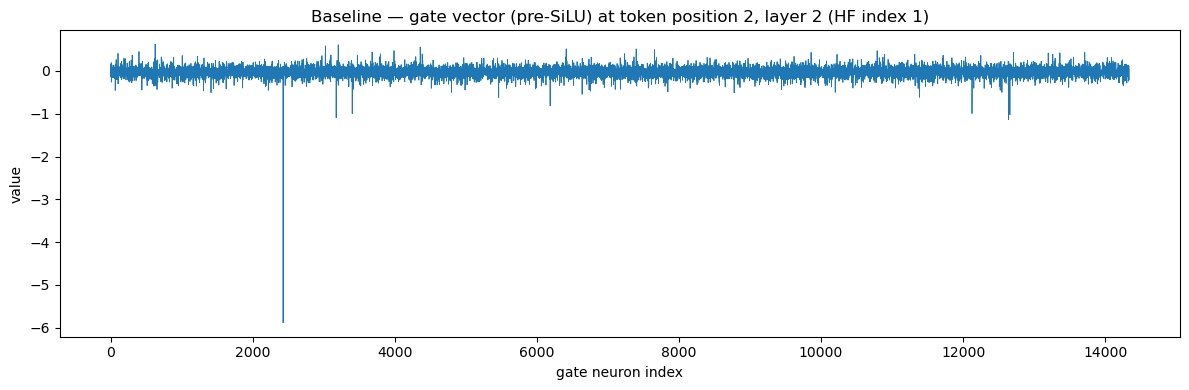

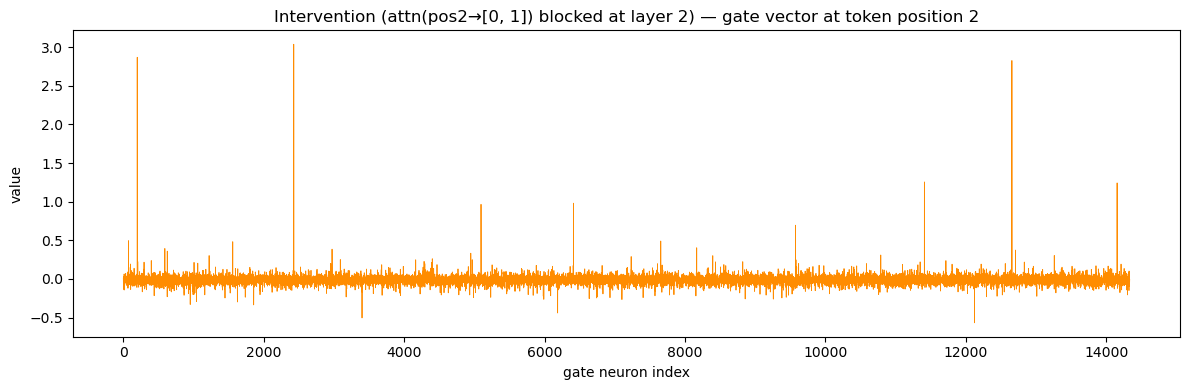

query pos 2, layer 2: neuron 2427: baseline = -5.883  intervention = 3.038
query pos 2, layer 2: sign changed after intervention: True


In [8]:
for qpos in QUERY_POSITIONS:
    key_positions = KEY_POS_TO_BLOCK[qpos]

    for L in LAYERS_TO_TEST:
        label = LAYER_LABELS[L]
        r = results[qpos][L]

        plot_specs = [
            ("baseline", r['gate_baseline'], 'C0',
             f"Baseline — gate vector (pre-SiLU) at token position {qpos}, {label} (HF index {L})"),
            ("intervention", r['gate_intervention'], 'darkorange',
             f"Intervention (attn(pos{qpos}→{key_positions}) blocked at {label}) — gate vector at token position {qpos}"),
        ]

        for name, gate_vec, color, title in plot_specs:
            fig, ax = plt.subplots(figsize=(12, 4))
            ax.plot(gate_vec, linewidth=0.6, color=color)
            ax.set_title(title)
            ax.set_xlabel("gate neuron index")
            ax.set_ylabel("value")
            plt.tight_layout()
            fname = f"gate_vector_{label.replace(' ', '')}_{name}_attn_ablation_pos{qpos}.pdf"
            plt.savefig(os.path.join(OUTPUT_DIR, fname))
            plt.show()

        print(f"query pos {qpos}, {label}: neuron {NEURON_IDX}: baseline = {r['gate_baseline'][NEURON_IDX]:.3f}  "
              f"intervention = {r['gate_intervention'][NEURON_IDX]:.3f}")
        print(f"query pos {qpos}, {label}: sign changed after intervention: "
              f"{np.sign(r['gate_baseline'][NEURON_IDX]) != np.sign(r['gate_intervention'][NEURON_IDX])}")

## Step 4 — Plot: gate vector at layer 2, three-way comparison

For each query position `q`: baseline (nothing blocked) vs. layer-2-only ablation vs. combined
ablation (layer 1 **and** layer 2 blocked, layer 1's perturbation propagated into layer 2's
input). Any difference between the second and third rows is the propagation effect.

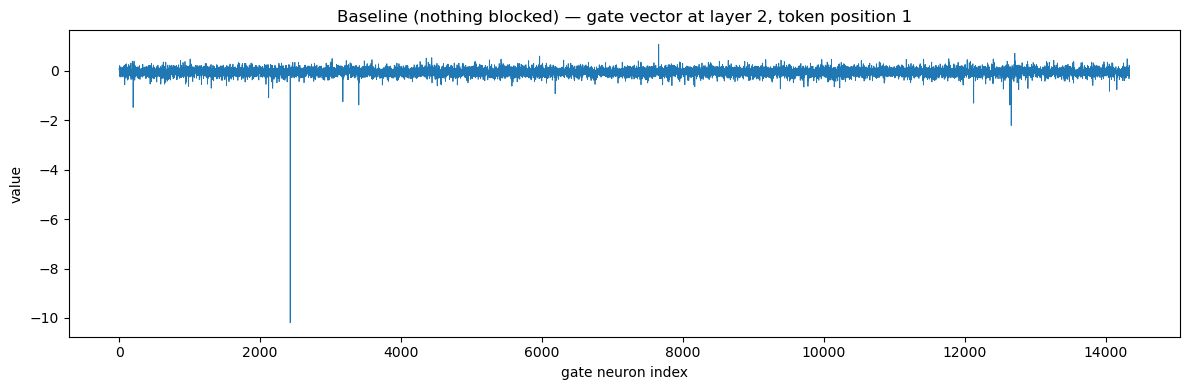

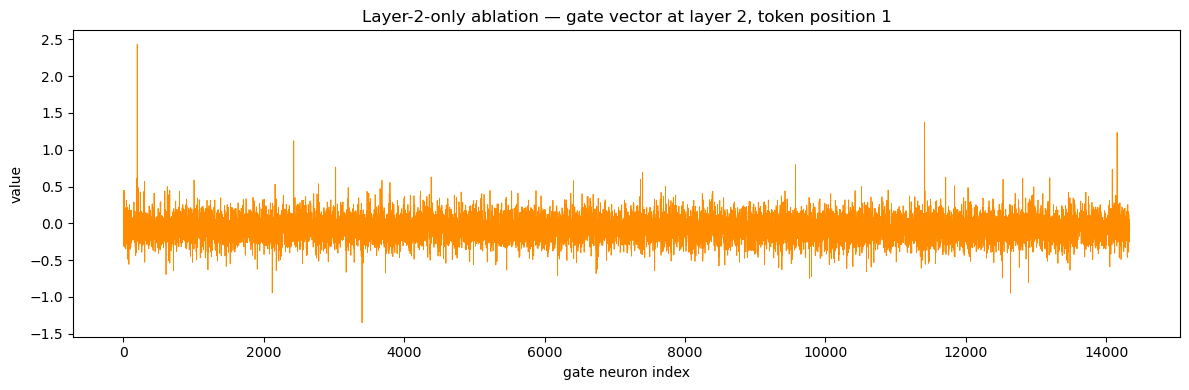

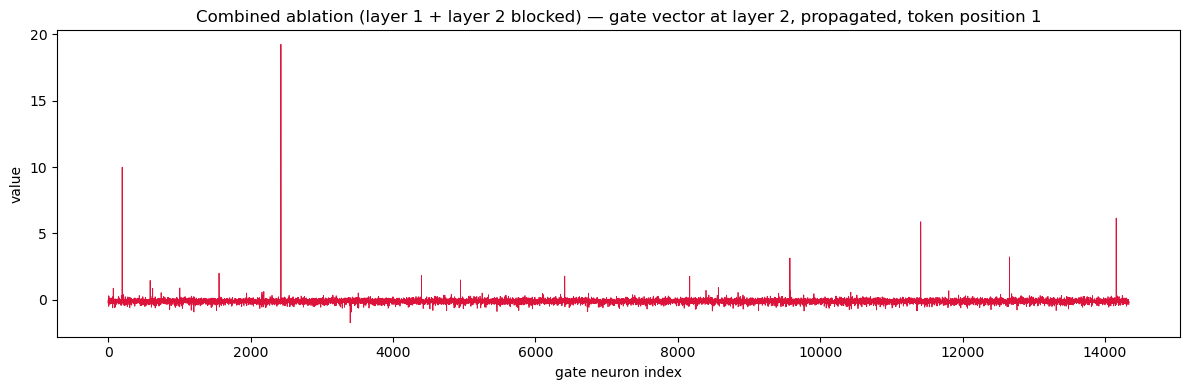

query pos 1, neuron 2427 at layer 2:
  baseline            = -10.1985
  layer-2-only        = 1.1219
  combined(1+2)       = 19.2634
  propagation delta (combined - layer-2-only) = 18.1415


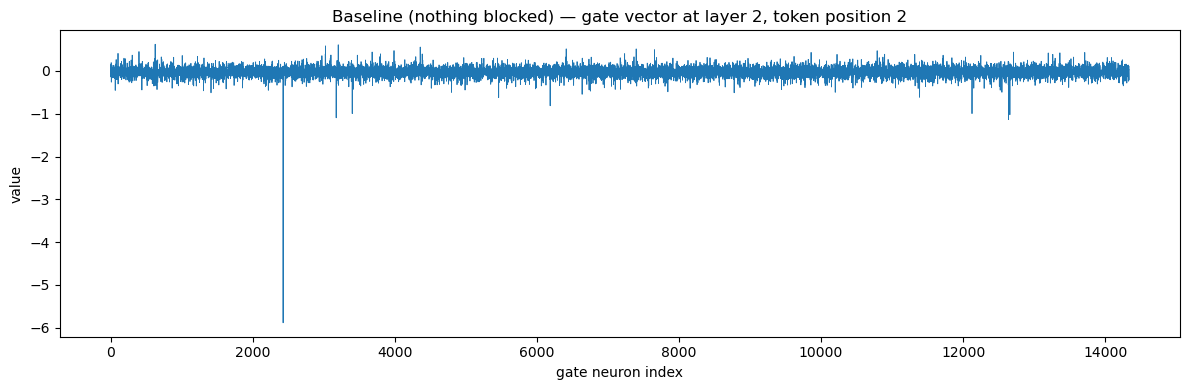

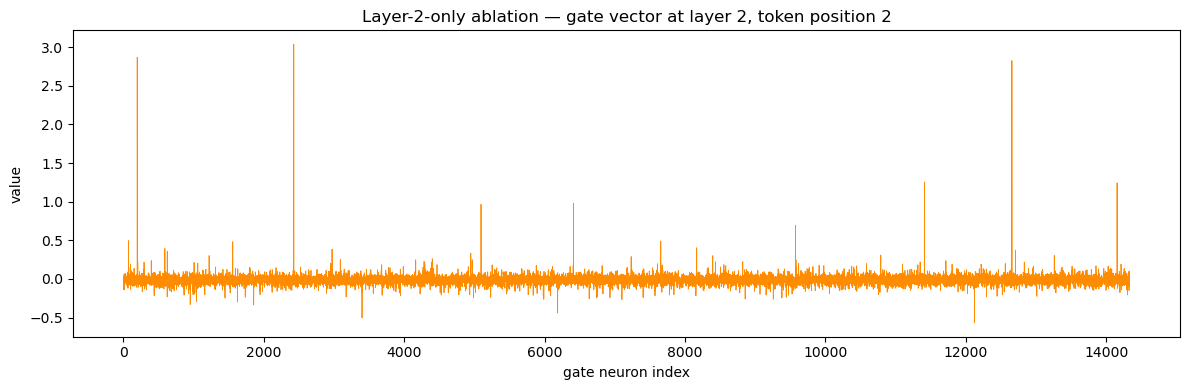

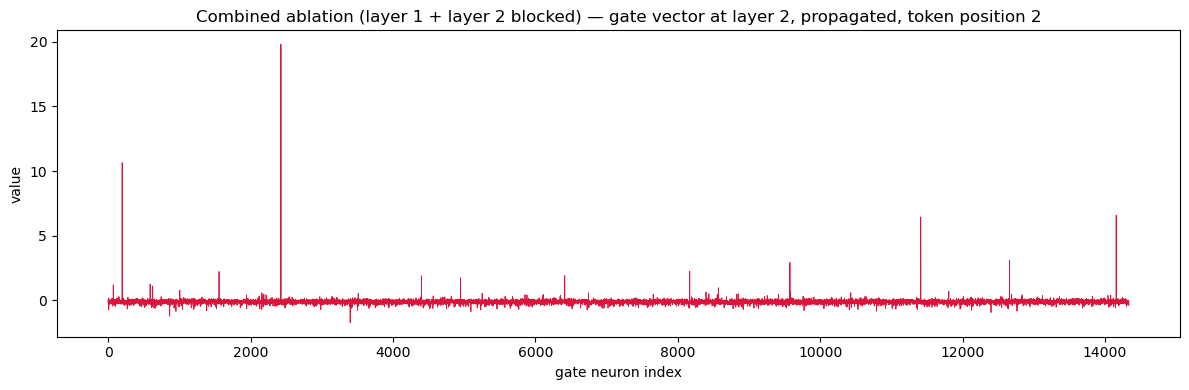

query pos 2, neuron 2427 at layer 2:
  baseline            = -5.8831
  layer-2-only        = 3.0380
  combined(1+2)       = 19.8151
  propagation delta (combined - layer-2-only) = 16.7771


In [9]:
for qpos in QUERY_POSITIONS:
    gate_baseline_L1 = results[qpos][1]['gate_baseline']
    gate_layer2_only_L1 = results[qpos][1]['gate_intervention']
    gate_combined_L1 = results[qpos]['combined']['gate_L1']

    plot_specs = [
        ("baseline", gate_baseline_L1, 'C0',
         f"Baseline (nothing blocked) — gate vector at layer 2, token position {qpos}"),
        ("layer2_only", gate_layer2_only_L1, 'darkorange',
         f"Layer-2-only ablation — gate vector at layer 2, token position {qpos}"),
        ("combined", gate_combined_L1, 'crimson',
         f"Combined ablation (layer 1 + layer 2 blocked) — gate vector at layer 2, propagated, token position {qpos}"),
    ]

    for name, gate_vec, color, title in plot_specs:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(gate_vec, linewidth=0.6, color=color)
        ax.set_title(title)
        ax.set_xlabel("gate neuron index")
        ax.set_ylabel("value")
        plt.tight_layout()
        fname = f"gate_vector_layer2_propagation_{name}_pos{qpos}.pdf"
        plt.savefig(os.path.join(OUTPUT_DIR, fname))
        plt.show()

    print(f"query pos {qpos}, neuron {NEURON_IDX} at layer 2:")
    print(f"  baseline            = {gate_baseline_L1[NEURON_IDX]:.4f}")
    print(f"  layer-2-only        = {gate_layer2_only_L1[NEURON_IDX]:.4f}")
    print(f"  combined(1+2)       = {gate_combined_L1[NEURON_IDX]:.4f}")
    print(f"  propagation delta (combined - layer-2-only) = "
          f"{gate_combined_L1[NEURON_IDX] - gate_layer2_only_L1[NEURON_IDX]:.4f}")

## Step 5 — Cross-condition summary

In [10]:
for qpos in QUERY_POSITIONS:
    print(f"\n=== query pos {qpos} ===")

    rows = [
        ("layer-1-only",  results[qpos][0]['gate_baseline'][NEURON_IDX], results[qpos][0]['gate_intervention'][NEURON_IDX]),
        ("layer-2-only",  results[qpos][1]['gate_baseline'][NEURON_IDX], results[qpos][1]['gate_intervention'][NEURON_IDX]),
        ("combined@L2",   results[qpos][1]['gate_baseline'][NEURON_IDX], results[qpos]['combined']['gate_L1'][NEURON_IDX]),
    ]

    print(f"{'condition':<14}{'gate base':>12}{'gate interv':>14}{'sign flip':>12}")
    for name, base, interv in rows:
        flip = np.sign(base) != np.sign(interv)
        print(f"{name:<14}{base:>12.3f}{interv:>14.3f}{str(flip):>12}")

    print(f"\npropagation-specific gate delta at layer 2 (combined - layer-2-only) = "
          f"{results[qpos]['combined']['gate_L1'][NEURON_IDX] - results[qpos][1]['gate_intervention'][NEURON_IDX]:.4f}")


=== query pos 1 ===
condition        gate base   gate interv   sign flip
layer-1-only        -0.058        -0.035       False
layer-2-only       -10.198         1.122        True
combined@L2        -10.198        19.263        True

propagation-specific gate delta at layer 2 (combined - layer-2-only) = 18.1415

=== query pos 2 ===
condition        gate base   gate interv   sign flip
layer-1-only        -0.023        -0.004       False
layer-2-only        -5.883         3.038        True
combined@L2         -5.883        19.815        True

propagation-specific gate delta at layer 2 (combined - layer-2-only) = 16.7771


## Interpretation

The following applies independently to each query position in `QUERY_POSITIONS`:

- **`layer-1-only` and `layer-2-only` rows** reproduce the original independent-layer result:
  whether each layer's self-attention, in isolation, is sufficient to flip the sign of
  `gate[2427]`.

- **`combined@L2` vs. `layer-2-only`** is the propagation test. If `combined@L2` is close to
  `layer-2-only` (small propagation delta): layer 2's own local attention block already
  accounts for essentially all of the effect at layer 2, and layer 1's ablation does not
  meaningfully propagate forward — layer 2 is "self-sufficient" for this effect.

- **If `combined@L2` diverges substantially from `layer-2-only`** (large propagation delta):
  layer 1's ablation is causally contributing to what happens at layer 2, independent of
  layer 2's own local block — i.e. the effect is genuinely propagated through the residual
  stream from layer 1 into layer 2, not just re-derived locally at layer 2. This would support
  treating layers 1–2 as a joint circuit rather than two independent single-layer causes.

- The sanity-check assertion in Step 2b (`combined` layer-1 readout == `layer-1-only`
  intervention) should always pass given the model's strict causal depth-wise structure; if it
  ever fails, suspect non-determinism (e.g. a non-greedy/sampling op somewhere) or a hook
  registered on the wrong module.

- Comparing results **across `QUERY_POSITIONS`** (1 vs. 2) additionally tests whether the
  gate-vector sign flip and propagation behaviour generalize beyond token position 1, or are
  specific to the position-1/position-0 relationship originally observed.